In [1]:
import pandas as pd, numpy as np, os
from db_queries import get_population, get_covariate_estimates, get_outputs, get_ids
import vivarium.artifact as art
from get_draws.api import get_draws
import matplotlib.pyplot as plt

In [2]:
location = 'india'


l = get_ids('location')
location_id = l.loc[l.location_name==location.title()].location_id.values[0]
results_dir = '/mnt/team/simulation_science/pub/models/vivarium_gates_lsff_2026/results/model1.1/maternal/rice/india/2026_08_28_18_23_34/results/'
# results_dir = results_dir + location + '/'
# now get most recent timestep for specified location
# results_dir = results_dir + sorted(os.listdir(results_dir))[len(os.listdir(results_dir))-1] + '/results/'
# artifact_dir = '/mnt/team/simulation_science/pub/models/vivarium_gates_lsff_2026/artifacts/legacy_1.0/maternal/nigeria.hdf'
artifact_dir = f'/mnt/team/simulation_science/pub/models/vivarium_gates_lsff_2026/artifacts/model1.1/maternal/rice/india.hdf'
results_dir

'/mnt/team/simulation_science/pub/models/vivarium_gates_lsff_2026/results/model1.1/maternal/rice/india/2026_08_28_18_23_34/results/'

# First, load artifact

In [3]:
art = art.Artifact(artifact_dir, filter_terms=['sex==Female','age_start>5','age_end<=60'])

In [4]:
def add_age_group(data):
    data = data.copy() if 'age_start' in data.columns else data.reset_index()
    data['age_group'] = (data.age_start.astype(int).astype(str)
                         + '_to_' + (data.age_end.astype(int) - 1).astype(str))
    return data

In [5]:
art.keys

['metadata.keyspace',
 'metadata.locations',
 'population.location',
 'population.structure',
 'population.age_bins',
 'population.demographic_dimensions',
 'population.theoretical_minimum_risk_life_expectancy',
 'population.infant_male_percentage',
 'population.wealth_quintile_probabilities',
 'cause.all_causes.cause_specific_mortality_rate',
 'vehicle.name',
 'covariate.age_specific_fertility_rate.estimate',
 'covariate.stillbirth_28_weeks_to_live_birth_ratio.estimate',
 'cause.maternal_abortion_and_miscarriage.raw_incidence_rate',
 'cause.ectopic_pregnancy.raw_incidence_rate',
 'risk_factor.low_birth_weight_and_short_gestation.exposure',
 'risk_factor.low_birth_weight_and_short_gestation.distribution',
 'risk_factor.low_birth_weight_and_short_gestation.categories',
 'cause.maternal_disorders.raw_incidence_rate',
 'cause.maternal_disorders.incident_probability',
 'cause.maternal_disorders.cause_specific_mortality_rate',
 'cause.maternal_disorders.mortality_probability',
 'cause.mater

In [6]:
# load up pregnancy incidence
# equations found here: https://vivarium-research.readthedocs.io/en/latest/models/other_models/pregnancy/gbd_2021_closed_cohort/index.html
asfr = art.load('covariate.age_specific_fertility_rate.estimate')
sbr = art.load('covariate.stillbirth_28_weeks_to_live_birth_ratio.estimate')   # GBD 2023 split the covariate into 20/28-week variants; model 1.1 carries the 28-week one
inc_mis = art.load('cause.maternal_abortion_and_miscarriage.raw_incidence_rate')
inc_ect = art.load('cause.ectopic_pregnancy.raw_incidence_rate')
art_preg_inc = (asfr 
               + asfr * sbr.value.values[0]
               + inc_mis 
               + inc_ect)
art_preg_inc.head()

draw_0
sex    age_start age_end year_start year_end          
Female 10.0      15.0    2023       2024      0.000514
       15.0      20.0    2023       2024      0.010748
       20.0      25.0    2023       2024      0.108000
       25.0      30.0    2023       2024      0.139357
       30.0      35.0    2023       2024      0.088701

In [7]:
# load artifact MD data
art_md_mort = art.load('cause.maternal_disorders.cause_specific_mortality_rate')
art_mort_frac = art_md_mort / art_preg_inc * 100_000 # convert to ratio per 100,000 pregnancies
art_mort_frac.head()

draw_0
sex    age_start age_end year_start year_end            
Female 10.0      15.0    2023       2024       50.266103
       15.0      20.0    2023       2024      339.028792
       20.0      25.0    2023       2024       83.486863
       25.0      30.0    2023       2024       69.943640
       30.0      35.0    2023       2024       96.758831

In [8]:
# load artifact MD data
art_md_inc = art.load('cause.maternal_disorders.raw_incidence_rate')
art_mh_inc = art.load('cause.maternal_hemorrhage.raw_incidence_rate')
art_inc_frac = art_md_inc / art_preg_inc * 100_000 # convert to ratio per 100,000 pregnancies
art_mh_frac = art_mh_inc / art_preg_inc * 100_000 # convert to ratio per 100,000 pregnancies
art_inc_frac#.head()

draw_0
sex    age_start age_end year_start year_end              
Female 10.0      15.0    2023       2024      58073.149914
       15.0      20.0    2023       2024      48198.996514
       20.0      25.0    2023       2024      37937.690088
       25.0      30.0    2023       2024      40045.672896
       30.0      35.0    2023       2024      46921.105576
       35.0      40.0    2023       2024      55362.028945
       40.0      45.0    2023       2024      66698.004059
       45.0      50.0    2023       2024      81971.866621
       50.0      55.0    2023       2024      97168.530314
       55.0      60.0    2023       2024               NaN

In [9]:
art_mh_frac
    # zeros for 50-55 year olds

draw_0
sex    age_start age_end year_start year_end             
Female 10.0      15.0    2023       2024      4248.997990
       15.0      20.0    2023       2024      4257.343754
       20.0      25.0    2023       2024      1550.884537
       25.0      30.0    2023       2024      1291.020641
       30.0      35.0    2023       2024      1282.534220
       35.0      40.0    2023       2024      1660.821264
       40.0      45.0    2023       2024      2049.543388
       45.0      50.0    2023       2024      3200.954614
       50.0      55.0    2023       2024      3409.176449
       55.0      60.0    2023       2024              NaN

# Now, load sim data

In [10]:
deaths = pd.read_parquet(results_dir + 'deaths')
deaths = deaths.loc[deaths.entity == 'maternal_disorders']
deaths.head()

,measure,entity_type,entity,sub_entity,age_group,anemia_status_at_birth,wealth_quintile,scenario,input_draw,random_seed,value
5,deaths,cause,maternal_disorders,maternal_disorders,10_to_14,invalid,1,baseline,0,2,0.0
6,deaths,cause,maternal_disorders,maternal_disorders,10_to_14,invalid,2,baseline,0,2,0.0
7,deaths,cause,maternal_disorders,maternal_disorders,10_to_14,invalid,3,baseline,0,2,0.0
8,deaths,cause,maternal_disorders,maternal_disorders,10_to_14,invalid,4,baseline,0,2,0.0
9,deaths,cause,maternal_disorders,maternal_disorders,10_to_14,invalid,5,baseline,0,2,0.0


In [11]:
# assert deaths.entity.unique() == ['maternal_disorders'], "deaths data has more causes than maternal disorders which is the only expected cause"

In [12]:
md_inc = pd.read_parquet(results_dir + 'transition_count_maternal_disorders')
md_inc = md_inc.loc[md_inc.sub_entity=='susceptible_to_maternal_disorders_to_maternal_disorders']
md_inc = (md_inc.groupby(['scenario','input_draw','age_group'])['value'].sum()
          + deaths.groupby(['scenario','input_draw','age_group'])['value'].sum()
         ).reset_index() 
# note that incident cases are only counted among surviving simulants, so we add in deaths here
md_inc.head()

,scenario,input_draw,age_group,value
0,baseline,0,10_to_14,302.0
1,baseline,0,15_to_19,4645.0
2,baseline,0,20_to_24,45429.0
3,baseline,0,25_to_29,68934.0
4,baseline,0,30_to_34,52473.0


In [13]:
mh_inc = pd.read_parquet(results_dir + 'transition_count_maternal_hemorrhage')
mh_inc = mh_inc.loc[mh_inc.sub_entity=='susceptible_to_maternal_hemorrhage_to_maternal_hemorrhage']
mh_inc.head()

,measure,entity_type,entity,sub_entity,age_group,anemia_status_at_birth,wealth_quintile,scenario,input_draw,random_seed,value
0,transition_count,cause,maternal_hemorrhage,susceptible_to_maternal_hemorrhage_to_maternal...,10_to_14,invalid,1,baseline,0,2,0.0
1,transition_count,cause,maternal_hemorrhage,susceptible_to_maternal_hemorrhage_to_maternal...,10_to_14,invalid,2,baseline,0,2,0.0
2,transition_count,cause,maternal_hemorrhage,susceptible_to_maternal_hemorrhage_to_maternal...,10_to_14,invalid,3,baseline,0,2,0.0
3,transition_count,cause,maternal_hemorrhage,susceptible_to_maternal_hemorrhage_to_maternal...,10_to_14,invalid,4,baseline,0,2,0.0
4,transition_count,cause,maternal_hemorrhage,susceptible_to_maternal_hemorrhage_to_maternal...,10_to_14,invalid,5,baseline,0,2,0.0


In [14]:
births = pd.read_parquet(results_dir + 'transition_count_pregnancy')
births = births.loc[births.sub_entity=='pregnant_to_parturition']
# add in deaths because they are not getting tracked in the parturition transition counts
births = (births.groupby(['scenario','input_draw','age_group'])['value'].sum()
          + deaths.groupby(['scenario','input_draw','age_group'])['value'].sum()).reset_index()
births.head()

,scenario,input_draw,age_group,value
0,baseline,0,10_to_14,384.0
1,baseline,0,15_to_19,10008.0
2,baseline,0,20_to_24,123575.0
3,baseline,0,25_to_29,178779.0
4,baseline,0,30_to_34,117409.0


In [15]:
births.loc[births.scenario=='baseline'].groupby('input_draw')['value'].sum().unique()

array([500000.])

In [16]:
n_simulants_per_draw = 500_000
assert births.loc[births.scenario=='baseline'].groupby('input_draw')['value'].sum().unique() == [n_simulants_per_draw], "Number of births does not match expected number of simulants"

In [17]:
cols = ['scenario','input_draw','age_group']
mort_frac_births = ((deaths.groupby(cols).sum() / births.groupby(cols).sum() * 100_000)
                    .groupby([c for c in cols if c != 'input_draw'])['value'].describe(percentiles=[0.025,0.975]))
inc_frac_births = ((md_inc.groupby(cols).sum() / births.groupby(cols).sum() * 100_000)
                    .groupby([c for c in cols if c != 'input_draw'])['value'].describe(percentiles=[0.025,0.975]))
mh_frac_births = ((mh_inc.groupby(cols).sum() / births.groupby(cols).sum() * 100_000)
                     .groupby([c for c in cols if c != 'input_draw'])['value'].describe(percentiles=[0.025,0.975]))
mort_frac_births.head()

/tmp/ipykernel_3070051/3074800288.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  mort_frac_births = ((deaths.groupby(cols).sum() / births.groupby(cols).sum() * 100_000)


/tmp/ipykernel_3070051/3074800288.py:6: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  mh_frac_births = ((mh_inc.groupby(cols).sum() / births.groupby(cols).sum() * 100_000)


count        mean  std         min        2.5%  \
scenario age_group                                                   
baseline 10_to_14     1.0    0.000000  NaN    0.000000    0.000000   
         15_to_19     1.0  389.688249  NaN  389.688249  389.688249   
         20_to_24     1.0   78.494841  NaN   78.494841   78.494841   
         25_to_29     1.0   63.206529  NaN   63.206529   63.206529   
         30_to_34     1.0   91.134410  NaN   91.134410   91.134410   

                           50%       97.5%         max  
scenario age_group                                      
baseline 10_to_14     0.000000    0.000000    0.000000  
         15_to_19   389.688249  389.688249  389.688249  
         20_to_24    78.494841   78.494841   78.494841  
         25_to_29    63.206529   63.206529   63.206529  
         30_to_34    91.134410   91.134410   91.134410

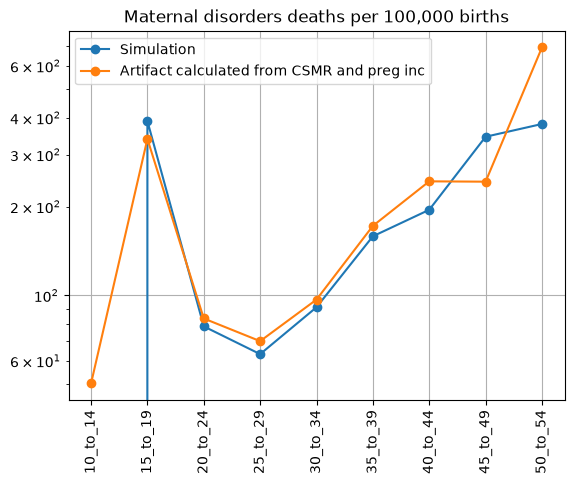

In [18]:
sim = mort_frac_births.reset_index().loc[mort_frac_births.reset_index().scenario
                                        =='baseline']

plt.plot(sim.age_group, sim['mean'], marker='o', label='Simulation')
plt.fill_between(sim.age_group, sim['2.5%'], sim['97.5%'], alpha=0.2)
a = art_mort_frac[[c for c in art_mort_frac.columns if int(c.split('_')[1]) in deaths.input_draw.unique()]]
a = a.apply(pd.DataFrame.describe, percentiles=[0.025,0.975], axis=1)
plt.plot(sim.age_group.iloc[:len(a)], a['mean'], marker='o', label='Artifact calculated from CSMR and preg inc')
plt.fill_between(sim.age_group.iloc[:len(a)], a['2.5%'], a['97.5%'], alpha=0.3)

plt.xticks(rotation=90)
plt.legend()
plt.grid()
plt.title('Maternal disorders deaths per 100,000 births')
plt.semilogy()
plt.show()
# a little off in our edge age groups but otherwise looking good

In [19]:
deaths = deaths.loc[deaths.entity=='maternal_disorders']
deaths = deaths.groupby(['age_group','scenario','input_draw'])['value'].sum().reset_index()
deaths = deaths.groupby(['age_group','scenario'])['value'].describe(percentiles=[0.025,0.975]).reset_index()
deaths.head()

,age_group,scenario,count,mean,std,min,2.5%,50%,97.5%,max
0,10_to_14,baseline,1.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0
1,10_to_14,intervention,1.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0
2,10_to_14,zero,1.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0
3,15_to_19,baseline,1.0,39.0,NaN,39.0,39.0,39.0,39.0,39.0
4,15_to_19,intervention,1.0,39.0,NaN,39.0,39.0,39.0,39.0,39.0


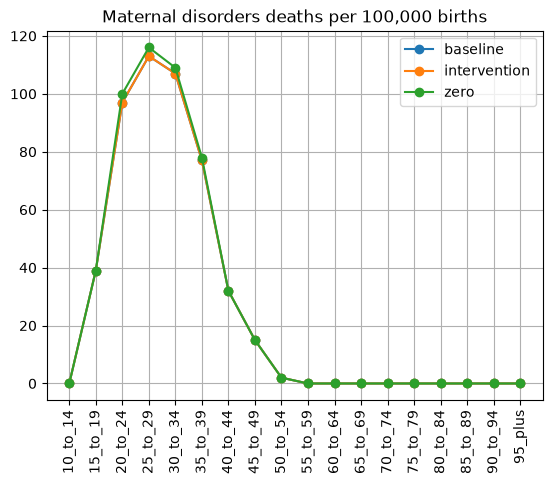

In [20]:
for scenario in deaths.scenario.unique(): 
    sim = deaths.loc[deaths.scenario==scenario]
    plt.plot(sim.age_group, sim['mean'], marker='o', label=scenario)
    #plt.fill_between(sim.age, sim['2.5%'], sim['97.5%'], alpha=0.2)

plt.xticks(rotation=90)
plt.legend()
plt.grid()
plt.title('Maternal disorders deaths per 100,000 births')
#plt.semilogy()
plt.show()

# ok this looks as expected!
# zero coverage should be the highest, followed by baseline
# then the remaining scenarios should all overlap below baseline

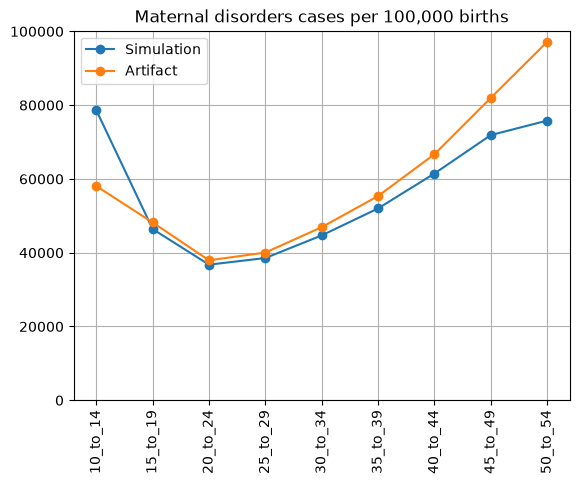

In [21]:
sim = inc_frac_births.reset_index().loc[inc_frac_births.reset_index().scenario
                                        =='baseline']
plt.plot(sim.age_group, sim['mean'], marker='o', label='Simulation')
plt.fill_between(sim.age_group, sim['2.5%'], sim['97.5%'], alpha=0.2)
a = art_inc_frac[[c for c in art_inc_frac.columns if int(c.split('_')[1]) in mh_inc.input_draw.unique()]]
a = a.apply(pd.DataFrame.describe, percentiles=[0.025,0.975], axis=1)
plt.plot(sim.age_group.iloc[:len(a)], a['mean'], marker='o', label='Artifact')
plt.fill_between(sim.age_group.iloc[:len(a)], a['2.5%'], a['97.5%'], alpha=0.3)
plt.xticks(rotation=90)
plt.legend()
plt.grid()
plt.ylim(ymin=0)
plt.title('Maternal disorders cases per 100,000 births')
plt.show()

# it's looking a little high... what if we don't add in deaths?

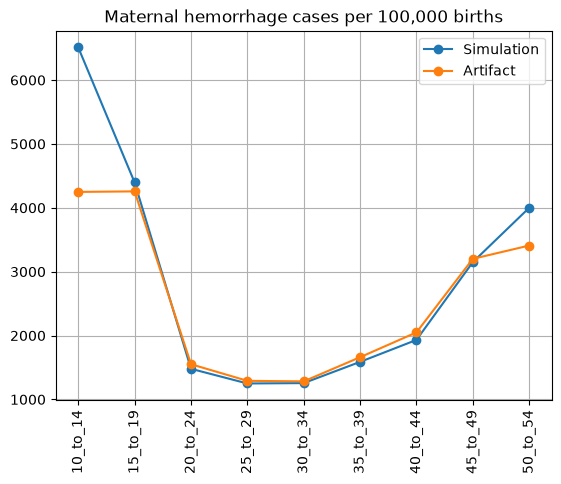

In [22]:
sim = mh_frac_births.reset_index().loc[mh_frac_births.reset_index().scenario
                                        =='baseline']

plt.plot(sim.age_group, sim['mean'], marker='o', label='Simulation')
plt.fill_between(sim.age_group, sim['2.5%'], sim['97.5%'], alpha=0.2)
a = art_mh_frac#[[c for c in art_mh_frac.columns if int(c.split('_')[1]) in mh_inc.input_draw.unique()]]
a = a.apply(pd.DataFrame.describe, percentiles=[0.025,0.975], axis=1)
plt.plot(sim.age_group.iloc[:len(a)], a['mean'], marker='o', label='Artifact')
plt.fill_between(sim.age_group.iloc[:len(a)], a['2.5%'], a['97.5%'], alpha=0.3)
plt.xticks(rotation=90)
plt.legend()
plt.grid()
plt.title('Maternal hemorrhage cases per 100,000 births')
plt.show()

In [23]:
preg_inc = art_preg_inc.reset_index()
preg_inc['age_group'] = (preg_inc.age_start.astype(int).astype(str) + '_to_' + (preg_inc.age_end.astype(int)-1).astype(str))
preg_inc = preg_inc.set_index('age_group')[[c for c in preg_inc.columns if 'draw' in c]]
preg_inc = preg_inc.stack().reset_index().rename(columns={'level_1':'input_draw',0:'value'})
preg_inc['input_draw'] = preg_inc.input_draw.str.split('_', expand=True)[1].astype(int)
preg_inc = preg_inc.set_index(['age_group','input_draw'])
preg_inc

,,value
age_group,input_draw,
10_to_14,0,0.000514
15_to_19,0,0.010748
20_to_24,0,0.108000
25_to_29,0,0.139357
30_to_34,0,0.088701
35_to_39,0,0.037751
40_to_44,0,0.014498
45_to_49,0,0.004212
50_to_54,0,0.000512


In [24]:
# what about YLDs?
ylds = pd.read_parquet(results_dir + 'ylds')
ylds_per_birth = (ylds.groupby(cols + ['entity']).sum() / births.groupby(cols).sum())[['value']]
yld_rate = (ylds_per_birth.reset_index().set_index(['age_group','input_draw','scenario','entity']) * preg_inc).dropna()
yld_rate = yld_rate.groupby([c for c in cols if c != 'input_draw'] + ['entity'])['value'].describe(percentiles=[0.025,0.975])
ylds

/tmp/ipykernel_3070051/2452861579.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ylds_per_birth = (ylds.groupby(cols + ['entity']).sum() / births.groupby(cols).sum())[['value']]


,measure,entity_type,entity,sub_entity,age_group,anemia_status_at_birth,wealth_quintile,scenario,input_draw,random_seed,value
0,ylds,cause,pregnancy,pregnant,10_to_14,invalid,1,baseline,0,2,0.0
1,ylds,cause,pregnancy,parturition,10_to_14,invalid,1,baseline,0,2,0.0
2,ylds,cause,pregnancy,postpartum,10_to_14,invalid,1,baseline,0,2,0.0
3,ylds,cause,maternal_disorders,maternal_disorders,10_to_14,invalid,1,baseline,0,2,0.0
4,ylds,cause,maternal_hemorrhage,maternal_hemorrhage,10_to_14,invalid,1,baseline,0,2,0.0
...,...,...,...,...,...,...,...,...,...,...,...
94495,ylds,cause,pregnancy,postpartum,95_plus,severe,5,baseline,0,9,0.0
94496,ylds,cause,maternal_disorders,maternal_disorders,95_plus,severe,5,baseline,0,9,0.0
94497,ylds,cause,maternal_hemorrhage,maternal_hemorrhage,95_plus,severe,5,baseline,0,9,0.0
94498,ylds,cause,all_causes,all_causes,95_plus,severe,5,baseline,0,9,0.0


In [25]:
YEAR_START = 2021 
gbd_ylds = get_draws(release_id=9,
                    year_id=YEAR_START, 
                    source='como',
                    gbd_id_type='cause_id',
                    gbd_id=366,
                    measure_id=3,
                    metric_id=3,
                    sex_id=2,
                    age_group_id=list(range(7,16)),
                    location_id=location_id)
gbd_ylds

/ihme/homes/abie/projects/2026/vivarium_gates_lsff_2026/.snakemake_envs/artifact/lib/python3.11/site-packages/get_draws/api.py:194: UserWarning: No version_id was specified, so get_draws will automatically determine a best version ID to use from the given parameters. If you want to retrieve a specific version please pass a version_id directly.
  warnings.warn(


,year_id,sex_id,age_group_id,measure_id,cause_id,draw_0,draw_1,draw_2,draw_3,draw_4,...,draw_493,draw_494,draw_495,draw_496,draw_497,draw_498,draw_499,location_id,metric_id,version_id
0,2021,2,7,3,366,0.000001,5.582349e-07,4.553748e-07,8.277391e-07,8.518911e-07,...,9.624699e-07,5.345053e-07,7.415271e-07,5.510156e-07,7.631717e-07,5.550409e-07,9.110967e-07,163,3,1471
1,2021,2,8,3,366,0.000088,4.700671e-05,6.007523e-05,6.633558e-05,5.892945e-05,...,6.304650e-05,8.413602e-05,8.580294e-05,3.942879e-05,1.096727e-04,6.515886e-05,9.250132e-05,163,3,1471
2,2021,2,9,3,366,0.000656,4.455094e-04,4.827691e-04,5.696272e-04,5.187082e-04,...,5.739908e-04,8.908434e-04,5.753894e-04,3.986208e-04,8.545966e-04,6.003510e-04,7.062753e-04,163,3,1471
3,2021,2,10,3,366,0.000889,7.626940e-04,6.530182e-04,9.462685e-04,7.624369e-04,...,8.569952e-04,8.853835e-04,7.506321e-04,5.799863e-04,1.235667e-03,1.177357e-03,1.250251e-03,163,3,1471
4,2021,2,11,3,366,0.001016,8.223302e-04,7.018327e-04,9.872014e-04,7.976588e-04,...,9.186973e-04,8.931989e-04,8.282037e-04,5.708122e-04,1.294792e-03,1.646815e-03,1.327881e-03,163,3,1471
5,2021,2,12,3,366,0.000804,6.165786e-04,5.568986e-04,7.459288e-04,6.693951e-04,...,6.526579e-04,7.115308e-04,6.661828e-04,4.824903e-04,9.493690e-04,1.335111e-03,1.001522e-03,163,3,1471
6,2021,2,13,3,366,0.000618,4.852444e-04,3.871868e-04,4.695279e-04,5.463847e-04,...,3.601430e-04,4.974382e-04,4.954468e-04,3.338089e-04,5.543182e-04,7.778822e-04,7.109478e-04,163,3,1471
7,2021,2,14,3,366,0.000460,3.131736e-04,2.975517e-04,3.170723e-04,3.640107e-04,...,2.281666e-04,3.721197e-04,3.899829e-04,2.544853e-04,3.515690e-04,5.115842e-04,4.682284e-04,163,3,1471
8,2021,2,15,3,366,0.000239,1.809889e-04,1.855608e-04,1.657171e-04,1.769047e-04,...,1.381052e-04,2.464032e-04,1.785126e-04,1.500432e-04,2.334391e-04,3.076632e-04,2.541604e-04,163,3,1471


In [26]:
# MD anemia YLDs
from db_queries import get_ids
x = get_draws(release_id=9,
                    year_id=YEAR_START,
                    source='como',
                    gbd_id_type='sequela_id',
                    gbd_id=[182,183,184],
                    measure_id=3,
                    metric_id=3,
                    sex_id=2,
                    age_group_id=list(range(7,16)),
                    location_id=location_id)
x = x.merge(get_ids('age_group'), on='age_group_id')
x['age_start'] = x.age_group_name.str.split(' to ', expand=True)[0].astype(float)
x['age_end'] = x.age_group_name.str.split(' to ', expand=True)[1].astype(float) + 1
x['sex'] = 'Female'
x = x.groupby(['sex','age_start','age_end',])[[c for c in x.columns if 'draw' in c]].sum()
x

/ihme/homes/abie/projects/2026/vivarium_gates_lsff_2026/.snakemake_envs/artifact/lib/python3.11/site-packages/get_draws/api.py:194: UserWarning: No version_id was specified, so get_draws will automatically determine a best version ID to use from the given parameters. If you want to retrieve a specific version please pass a version_id directly.
  warnings.warn(


draw_0        draw_1        draw_2  \
sex    age_start age_end                                             
Female 10.0      15.0     1.056632e-08  1.070710e-08  1.429506e-08   
       15.0      20.0     5.325354e-06  3.880150e-06  5.982971e-06   
       20.0      25.0     9.190638e-05  4.861176e-05  7.669458e-05   
       25.0      30.0     1.093118e-04  7.820962e-05  7.005768e-05   
       30.0      35.0     5.242988e-05  4.739377e-05  3.719561e-05   
       35.0      40.0     2.256661e-05  1.468145e-05  1.791609e-05   
       40.0      45.0     6.749541e-06  7.057665e-06  5.433895e-06   
       45.0      50.0     2.824977e-06  2.988778e-06  1.501307e-06   
       50.0      55.0     5.810042e-07  5.001416e-07  5.037792e-07   

                                draw_3        draw_4        draw_5  \
sex    age_start age_end                                             
Female 10.0      15.0     1.841532e-08  1.540612e-08  2.123299e-08   
       15.0      20.0     1.291449e-05  5.526945e-06  6.911111e-06   
       20.0      25.0     1.700884e-04  5.956256e-05  7.692620e-05   
       25.0      30.0     1.341543e-04  8.148301e-05  8.367164e-05   
       30.0      35.0     1.110713e-04  5.729998e-05  6.637001e-05   
       35.0      40.0     4.841197e-05  3.666476e-05  3.567743e-05   
       40.0      45.0     1.676057e-05  1.160513e-05  1.455509e-05   
       45.0      50.0     6.757146e-06  3.536246e-06  4.821645e-06   
       50.0      55.0     6.991617e-07  7.451201e-07  8.178379e-07   

                                draw_6        draw_7        draw_8  \
sex    age_start age_end                                             
Female 10.0      15.0     6.879006e-09  2.212953e-08  9.099850e-09   
       15.0      20.0     5.091290e-06  1.281784e-05  4.771864e-06   
       20.0      25.0     6.201673e-05  1.461696e-04  6.347575e-05   
       25.0      30.0     7.840105e-05  1.249816e-04  8.325015e-05   
       30.0      35.0     4.053179e-05  5.650918e-05  5.037178e-05   
       35.0      40.0     1.148488e-05  2.783906e-05  1.079356e-05   
       40.0      45.0     3.482778e-06  5.119186e-06  4.225793e-06   
       45.0      50.0     2.387096e-06  2.489639e-06  1.869801e-06   
       50.0      55.0     3.240416e-07  4.666421e-07  4.634761e-07   

                                draw_9  ...      draw_490      draw_491  \
sex    age_start age_end                ...                               
Female 10.0      15.0     1.827215e-08  ...  2.173855e-08  1.872103e-08   
       15.0      20.0     1.059312e-05  ...  8.985313e-06  1.360065e-05   
       20.0      25.0     7.580308e-05  ...  7.010979e-05  1.464828e-04   
       25.0      30.0     1.455126e-04  ...  1.056694e-04  9.464737e-05   
       30.0      35.0     5.255899e-05  ...  8.136708e-05  6.054944e-05   
       35.0      40.0     2.268893e-05  ...  3.312073e-05  1.777742e-05   
       40.0      45.0     6.915456e-06  ...  1.140176e-05  7.074228e-06   
       45.0      50.0     4.008993e-06  ...  2.207594e-06  2.062688e-06   
       50.0      55.0     7.031672e-07  ...  5.864789e-07  5.231137e-07   

                              draw_492      draw_493      draw_494  \
sex    age_start age_end                                             
Female 10.0      15.0     1.117903e-08  2.040478e-08  1.195480e-08   
       15.0      20.0     3.821828e-06  7.196468e-06  1.096653e-05   
       20.0      25.0     4.749487e-05  1.042777e-04  2.437123e-04   
       25.0      30.0     6.229565e-05  8.185199e-05  1.339812e-04   
       30.0      35.0     3.889930e-05  3.637354e-05  5.621367e-05   
       35.0      40.0     1.616103e-05  1.362669e-05  2.470074e-05   
       40.0      45.0     4.145731e-06  5.954253e-06  6.424393e-06   
       45.0      50.0     1.193696e-06  3.526174e-06  1.854694e-06   
       50.0      55.0     2.644316e-07  5.937612e-07  3.582829e-07   

                              draw_495      draw_496      draw_497  \
sex    age_start age_end                            

In [27]:
# MD YLDs prepped
y = gbd_ylds.merge(get_ids('age_group'), on='age_group_id')
y['age_start'] = y.age_group_name.str.split(' to ', expand=True)[0].astype(float)
y['age_end'] = y.age_group_name.str.split(' to ', expand=True)[1].astype(float) + 1
y['sex'] = 'Female'
y = y.set_index(['sex','age_start','age_end'])[[c for c in y.columns if 'draw' in c]]
y

draw_0        draw_1        draw_2        draw_3  \
sex    age_start age_end                                                       
Female 10.0      15.0     0.000001  5.582349e-07  4.553748e-07  8.277391e-07   
       15.0      20.0     0.000088  4.700671e-05  6.007523e-05  6.633558e-05   
       20.0      25.0     0.000656  4.455094e-04  4.827691e-04  5.696272e-04   
       25.0      30.0     0.000889  7.626940e-04  6.530182e-04  9.462685e-04   
       30.0      35.0     0.001016  8.223302e-04  7.018327e-04  9.872014e-04   
       35.0      40.0     0.000804  6.165786e-04  5.568986e-04  7.459288e-04   
       40.0      45.0     0.000618  4.852444e-04  3.871868e-04  4.695279e-04   
       45.0      50.0     0.000460  3.131736e-04  2.975517e-04  3.170723e-04   
       50.0      55.0     0.000239  1.809889e-04  1.855608e-04  1.657171e-04   

                                draw_4    draw_5        draw_6        draw_7  \
sex    age_start age_end                                                       
Female 10.0      15.0     8.518911e-07  0.000001  4.820014e-07  6.346629e-07   
       15.0      20.0     5.892945e-05  0.000086  4.600052e-05  7.181544e-05   
       20.0      25.0     5.187082e-04  0.000579  4.412922e-04  6.726827e-04   
       25.0      30.0     7.624369e-04  0.000760  8.119560e-04  8.691322e-04   
       30.0      35.0     7.976588e-04  0.000764  9.551553e-04  6.977048e-04   
       35.0      40.0     6.693951e-04  0.000650  7.576355e-04  5.347039e-04   
       40.0      45.0     5.463847e-04  0.000487  5.361858e-04  3.650914e-04   
       45.0      50.0     3.640107e-04  0.000359  3.732475e-04  2.576139e-04   
       50.0      55.0     1.769047e-04  0.000206  2.642647e-04  1.366341e-04   

                                draw_8        draw_9  ...  draw_490  draw_491  \
sex    age_start age_end                              ...                       
Female 10.0      15.0     8.507558e-07  8.657446e-07  ...  0.000002  0.000001   
       15.0      20.0     4.926277e-05  7.381580e-05  ...  0.000123  0.000096   
       20.0      25.0     4.282846e-04  4.946046e-04  ...  0.000682  0.000789   
       25.0      30.0     6.295693e-04  8.114603e-04  ...  0.000876  0.000925   
       30.0      35.0     6.733691e-04  8.324531e-04  ...  0.000775  0.000809   
       35.0      40.0     5.318039e-04  7.166450e-04  ...  0.000523  0.000537   
       40.0      45.0     4.968120e-04  5.395412e-04  ...  0.000355  0.000417   
       45.0      50.0     3.142145e-04  3.720394e-04  ...  0.000275  0.000307   
       50.0      55.0     2.002751e-04  2.188362e-04  ...  0.000187  0.000170   

                              draw_492      draw_493      draw_494  \
sex    age_start age_end                                             
Female 10.0      15.0     7.087144e-07  9.624699e-07  5.345053e-07   
       15.0      20.0     4.199666e-05  6.304650e-05  8.413602e-05   
       20.0      25.0     3.714761e-04  5.739908e-04  8.908434e-04   
       25.0      30.0     6.076214e-04  8.569952e-04  8.853835e-04   
       30.0      35.0     7.955417e-04  9.186973e-04  8.931989e-04   
       35.0      40.0     5.830403e-04  6.526579e-04  7.115308e-04   
       40.0      45.0     4.289526e-04  3.601430e-04  4.974382e-04   
       45.0      50.0     2.560245e-04  2.281666e-04  3.721197e-04   
       50.0      55.0     1.706125e-04  1.381052e-04  2.464032e-04   

                              draw_495      draw_496      draw_497  \
sex    age_start age_end                                             
Female 10.0      15.0     7.415271e-07  5.510156e-07  7.631717e-07   
       15.0      20.0     8.580294e-05  3.942879e-05  1.096727e-04   
       20.0      25.0     5.753894e-04  3.986208e-04  8.545966e-04   
       25.0      30.0     7.506321e-04  5.799863e-04  1.235667e-03   
       30.0      35.0     8.282037e-04  5.708122e-04  1.294792e-03   
       35.0      40.0     6.661828e-04  4.824903e-04  9.493690e-04   
       40.0      45.0     4.954468e-04  3.3

In [28]:
from db_queries import get_ids
g = y - x
g = g.reset_index().set_index(['age_start'])[[c for c in g.columns if 'draw' in c
                                and int(c.split('_')[1]) in ylds.input_draw.unique()]]
g = g.apply(pd.DataFrame.describe, percentiles=[0.025,0.975], axis=1).reset_index()
g

,age_start,count,mean,std,min,2.5%,50%,97.5%,max
0,10.0,1.0,0.000001,NaN,0.000001,0.000001,0.000001,0.000001,0.000001
1,15.0,1.0,0.000083,NaN,0.000083,0.000083,0.000083,0.000083,0.000083
2,20.0,1.0,0.000564,NaN,0.000564,0.000564,0.000564,0.000564,0.000564
3,25.0,1.0,0.000779,NaN,0.000779,0.000779,0.000779,0.000779,0.000779
4,30.0,1.0,0.000963,NaN,0.000963,0.000963,0.000963,0.000963,0.000963
5,35.0,1.0,0.000782,NaN,0.000782,0.000782,0.000782,0.000782,0.000782
6,40.0,1.0,0.000611,NaN,0.000611,0.000611,0.000611,0.000611,0.000611
7,45.0,1.0,0.000457,NaN,0.000457,0.000457,0.000457,0.000457,0.000457
8,50.0,1.0,0.000239,NaN,0.000239,0.000239,0.000239,0.000239,0.000239


In [29]:
md_ylds = yld_rate.copy().reset_index()
# md_ylds = md_ylds.loc[(md_ylds.entity=='maternal_disorders')
#                      &(md_ylds.scenario=='baseline')]
md_ylds

,scenario,age_group,entity,count,mean,std,min,2.5%,50%,97.5%,max
0,baseline,10_to_14,all_causes,1.0,1.413170e-05,NaN,1.413170e-05,1.413170e-05,1.413170e-05,1.413170e-05,1.413170e-05
1,baseline,10_to_14,anemia,1.0,1.412463e-05,NaN,1.412463e-05,1.412463e-05,1.412463e-05,1.412463e-05,1.412463e-05
2,baseline,10_to_14,maternal_disorders,1.0,7.073151e-09,NaN,7.073151e-09,7.073151e-09,7.073151e-09,7.073151e-09,7.073151e-09
3,baseline,10_to_14,maternal_hemorrhage,1.0,0.000000e+00,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
4,baseline,10_to_14,pregnancy,1.0,0.000000e+00,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...
130,zero,50_to_54,all_causes,1.0,5.621946e-06,NaN,5.621946e-06,5.621946e-06,5.621946e-06,5.621946e-06,5.621946e-06
131,zero,50_to_54,anemia,1.0,4.960461e-06,NaN,4.960461e-06,4.960461e-06,4.960461e-06,4.960461e-06,4.960461e-06
132,zero,50_to_54,maternal_disorders,1.0,6.614851e-07,NaN,6.614851e-07,6.614851e-07,6.614851e-07,6.614851e-07,6.614851e-07
133,zero,50_to_54,maternal_hemorrhage,1.0,0.000000e+00,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00


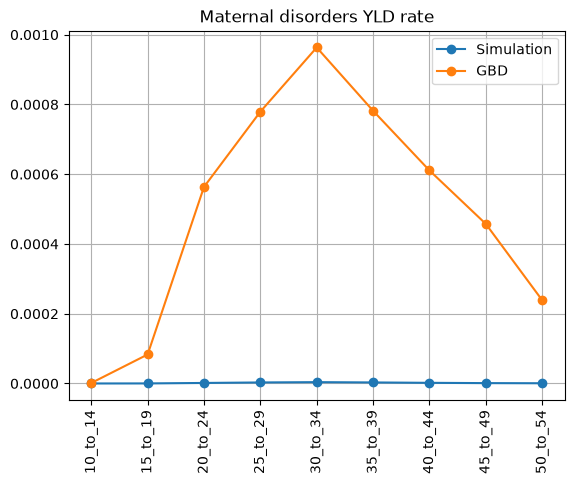

In [30]:
md_ylds = yld_rate.copy().reset_index()
md_ylds = md_ylds.loc[(md_ylds.entity=='maternal_disorders')
                     &(md_ylds.scenario=='baseline')]
plt.plot(md_ylds.reset_index().age_group, md_ylds['mean'], marker='o', label='Simulation')
plt.fill_between(md_ylds.age_group, md_ylds['2.5%'], md_ylds['97.5%'], alpha=0.3)
plt.plot(md_ylds.age_group, g['mean'], marker='o', label='GBD')
plt.fill_between(md_ylds.age_group, g['2.5%'], g['97.5%'], alpha=0.3)
#plt.semilogy()
plt.xticks(rotation=90)
plt.legend()
plt.title('Maternal disorders YLD rate')
plt.grid()

/tmp/ipykernel_3070051/2553362533.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  mort_frac= (deaths.groupby(cols).sum() / births.groupby(cols).sum())[['value']]


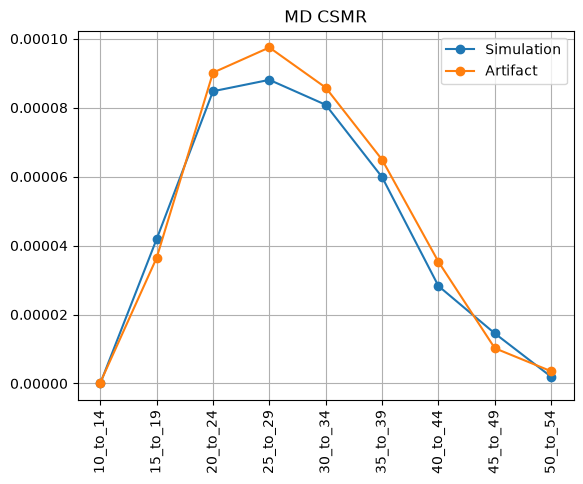

In [31]:
cols = ['scenario','input_draw','age_group']
deaths = pd.read_parquet(results_dir + 'deaths')
mort_frac= (deaths.groupby(cols).sum() / births.groupby(cols).sum())[['value']]
csmr = (mort_frac.reset_index().set_index(cols) * preg_inc).dropna()
csmr = csmr.groupby([c for c in cols if c != 'input_draw'])['value'].describe(percentiles=[0.025,0.975]).reset_index()
csmr = csmr.loc[csmr.scenario=='baseline']
plt.plot(csmr.reset_index().age_group, csmr['mean'], marker='o', label='Simulation')
plt.fill_between(csmr.reset_index().age_group, csmr['2.5%'], csmr['97.5%'], alpha=0.3)

a = art.load('cause.maternal_disorders.cause_specific_mortality_rate')
a = a[[c for c in a.columns if int(c.split('_')[1]) in ylds.input_draw.unique()]]
a = a.apply(pd.DataFrame.describe, percentiles=[0.025,0.975], axis=1).reset_index()
a = a.loc[a.age_end!=60]
plt.plot(csmr.reset_index().age_group, a['mean'], marker='o', label='Artifact')
plt.fill_between(csmr.reset_index().age_group, a['2.5%'], a['97.5%'], alpha=0.3)

plt.xticks(rotation=90)
plt.title('MD CSMR')
plt.grid()
plt.legend()

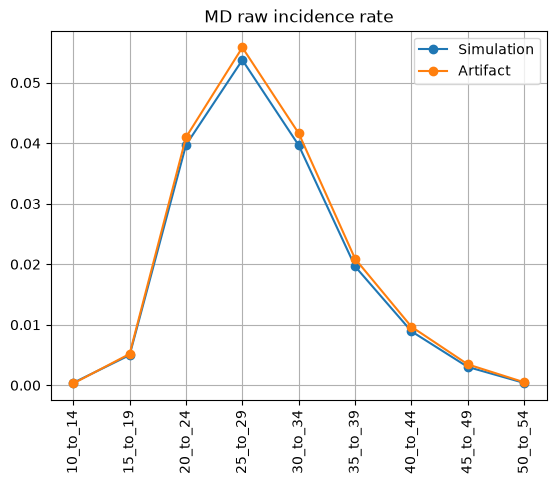

In [32]:
cols = ['scenario','input_draw','age_group']
inc_frac= (md_inc.groupby(cols).sum() / births.groupby(cols).sum())[['value']]
csmr = (inc_frac.reset_index().set_index(cols) * preg_inc).dropna()
csmr = csmr.groupby([c for c in cols if c != 'input_draw'])['value'].describe(percentiles=[0.025,0.975]).reset_index()
csmr = csmr.loc[csmr.scenario=='baseline']
plt.plot(csmr.reset_index().age_group, csmr['mean'], marker='o', label='Simulation')
plt.fill_between(csmr.reset_index().age_group, csmr['2.5%'], csmr['97.5%'], alpha=0.3)

a = art.load('cause.maternal_disorders.raw_incidence_rate')
a = a[[c for c in a.columns if int(c.split('_')[1]) in ylds.input_draw.unique()]]
a = a.apply(pd.DataFrame.describe, percentiles=[0.025,0.975], axis=1).reset_index()
a = a.loc[a.age_end!=60]
plt.plot(csmr.reset_index().age_group, a['mean'], marker='o', label='Artifact')
plt.fill_between(csmr.reset_index().age_group, a['2.5%'], a['97.5%'], alpha=0.3)

plt.xticks(rotation=90)
plt.title('MD raw incidence rate')
plt.grid()
plt.legend()

/tmp/ipykernel_3070051/3920017641.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  inc_frac= (mh_inc.groupby(cols).sum() / births.groupby(cols).sum())[['value']]


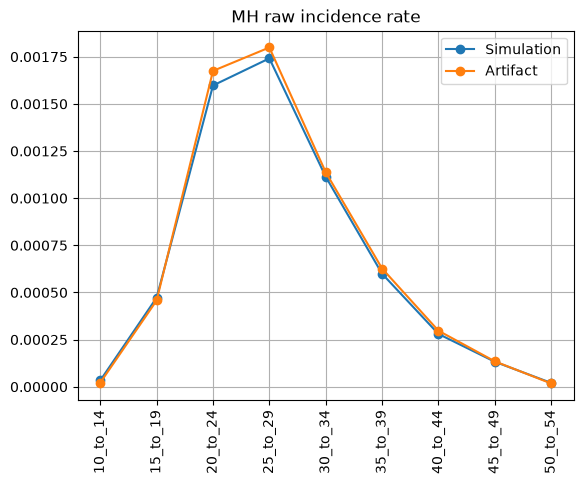

In [33]:
cols = ['scenario','input_draw','age_group']
inc_frac= (mh_inc.groupby(cols).sum() / births.groupby(cols).sum())[['value']]
csmr = (inc_frac.reset_index().set_index(cols) * preg_inc).dropna()
csmr = csmr.groupby([c for c in cols if c != 'input_draw'])['value'].describe(percentiles=[0.025,0.975]).reset_index()
csmr = csmr.loc[csmr.scenario=='baseline']
plt.plot(csmr.reset_index().age_group, csmr['mean'], marker='o', label='Simulation')
plt.fill_between(csmr.reset_index().age_group, csmr['2.5%'], csmr['97.5%'], alpha=0.3)

a = art.load('cause.maternal_hemorrhage.raw_incidence_rate')
a = a[[c for c in a.columns if int(c.split('_')[1]) in deaths.input_draw.unique()]]
a = a.apply(pd.DataFrame.describe, percentiles=[0.025,0.975], axis=1).reset_index()
a = a.loc[a.age_end!=60]
plt.plot(csmr.reset_index().age_group, a['mean'], marker='o', label='Artifact')
plt.fill_between(csmr.reset_index().age_group, a['2.5%'], a['97.5%'], alpha=0.3)

plt.xticks(rotation=90)
plt.title('MH raw incidence rate')
plt.grid()
plt.legend()

# Checking more artifact values

In [34]:
# MD anemia YLDs

x = get_draws(release_id=9,
                    year_id=YEAR_START,
                    source='como',
                    gbd_id_type='sequela_id',
                    gbd_id=[182,183,184],
                    measure_id=3,
                    metric_id=3,
                    sex_id=2,
                    age_group_id=list(range(7,16)),
                    location_id=location_id)
x = x.merge(get_ids('age_group'), on='age_group_id')
x['age_start'] = x.age_group_name.str.split(' to ', expand=True)[0].astype(float)
x['age_end'] = x.age_group_name.str.split(' to ', expand=True)[1].astype(float) + 1
x['sex'] = 'Female'
x['year_start'] = YEAR_START # UPDATE?
x['year_end'] = YEAR_START + 1 # UPDATE?
x = x.groupby(['sex','age_start','age_end','year_start','year_end'])[[c for c in x.columns if 'draw' in c]].sum()
x

/ihme/homes/abie/projects/2026/vivarium_gates_lsff_2026/.snakemake_envs/artifact/lib/python3.11/site-packages/get_draws/api.py:194: UserWarning: No version_id was specified, so get_draws will automatically determine a best version ID to use from the given parameters. If you want to retrieve a specific version please pass a version_id directly.
  warnings.warn(


draw_0        draw_1  \
sex    age_start age_end year_start year_end                               
Female 10.0      15.0    2021       2022      1.056632e-08  1.070710e-08   
       15.0      20.0    2021       2022      5.325354e-06  3.880150e-06   
       20.0      25.0    2021       2022      9.190638e-05  4.861176e-05   
       25.0      30.0    2021       2022      1.093118e-04  7.820962e-05   
       30.0      35.0    2021       2022      5.242988e-05  4.739377e-05   
       35.0      40.0    2021       2022      2.256661e-05  1.468145e-05   
       40.0      45.0    2021       2022      6.749541e-06  7.057665e-06   
       45.0      50.0    2021       2022      2.824977e-06  2.988778e-06   
       50.0      55.0    2021       2022      5.810042e-07  5.001416e-07   

                                                    draw_2        draw_3  \
sex    age_start age_end year_start year_end                               
Female 10.0      15.0    2021       2022      1.429506e-08  1.841532e-08   
       15.0      20.0    2021       2022      5.982971e-06  1.291449e-05   
       20.0      25.0    2021       2022      7.669458e-05  1.700884e-04   
       25.0      30.0    2021       2022      7.005768e-05  1.341543e-04   
       30.0      35.0    2021       2022      3.719561e-05  1.110713e-04   
       35.0      40.0    2021       2022      1.791609e-05  4.841197e-05   
       40.0      45.0    2021       2022      5.433895e-06  1.676057e-05   
       45.0      50.0    2021       2022      1.501307e-06  6.757146e-06   
       50.0      55.0    2021       2022      5.037792e-07  6.991617e-07   

                                                    draw_4        draw_5  \
sex    age_start age_end year_start year_end                               
Female 10.0      15.0    2021       2022      1.540612e-08  2.123299e-08   
       15.0      20.0    2021       2022      5.526945e-06  6.911111e-06   
       20.0      25.0    2021       2022      5.956256e-05  7.692620e-05   
       25.0      30.0    2021       2022      8.148301e-05  8.367164e-05   
       30.0      35.0    2021       2022      5.729998e-05  6.637001e-05   
       35.0      40.0    2021       2022      3.666476e-05  3.567743e-05   
       40.0      45.0    2021       2022      1.160513e-05  1.455509e-05   
       45.0      50.0    2021       2022      3.536246e-06  4.821645e-06   
       50.0      55.0    2021       2022      7.451201e-07  8.178379e-07   

                                                    draw_6        draw_7  \
sex    age_start age_end year_start year_end                               
Female 10.0      15.0    2021       2022      6.879006e-09  2.212953e-08   
       15.0      20.0    2021       2022      5.091290e-06  1.281784e-05   
       20.0      25.0    2021       2022      6.201673e-05  1.461696e-04   
       25.0      30.0    2021       2022      7.840105e-05  1.249816e-04   
       30.0      35.0    2021       2022      4.053179e-05  5.650918e-05   
       35.0      40.0    2021       2022      1.148488e-05  2.783906e-05   
       40.0      45.0    2021       2022      3.482778e-06  5.119186e-06   
       45.0      50.0    2021       2022      2.387096e-06  2.489639e-06   
       50.0      55.0    2021       2022      3.240416e-07  4.666421e-07   

                                                    draw_8        draw_9  ...  \
sex    age_start age_end year_start year_end                              ...   
Female 10.0      15.0    2021       2022      9.099850e-09  1.827215e-08  ...   
       15.0      20.0    2021       2022      4.771864e-06  1.059312e-05  ...   
       20.0      25.0    2021       2022      6.347575e-05  7.580308e-05  ...   
       25.0      30.0    2021       2022      8.325015e-05  1.455126e-04  ...   
       30.0      35.0    2021       2022      5.037178e-05  5.255899e-05  ...   
       35.0      40.0    2021       2022      1.079356e-05  2.268893e-05  ...   
       40.0      45.0    2021       2022      4.225793e-

In [35]:
# MD YLDs prepped
y = gbd_ylds.merge(get_ids('age_group'), on='age_group_id')
y['age_start'] = y.age_group_name.str.split(' to ', expand=True)[0].astype(float)
y['age_end'] = y.age_group_name.str.split(' to ', expand=True)[1].astype(float) + 1
y['sex'] = 'Female'
y['year_start'] = YEAR_START
y['year_end'] = YEAR_START + 1
y = y.set_index(['sex','age_start','age_end','year_start','year_end'])[[c for c in y.columns if 'draw' in c]]
y

draw_0        draw_1  \
sex    age_start age_end year_start year_end                           
Female 10.0      15.0    2021       2022      0.000001  5.582349e-07   
       15.0      20.0    2021       2022      0.000088  4.700671e-05   
       20.0      25.0    2021       2022      0.000656  4.455094e-04   
       25.0      30.0    2021       2022      0.000889  7.626940e-04   
       30.0      35.0    2021       2022      0.001016  8.223302e-04   
       35.0      40.0    2021       2022      0.000804  6.165786e-04   
       40.0      45.0    2021       2022      0.000618  4.852444e-04   
       45.0      50.0    2021       2022      0.000460  3.131736e-04   
       50.0      55.0    2021       2022      0.000239  1.809889e-04   

                                                    draw_2        draw_3  \
sex    age_start age_end year_start year_end                               
Female 10.0      15.0    2021       2022      4.553748e-07  8.277391e-07   
       15.0      20.0    2021       2022      6.007523e-05  6.633558e-05   
       20.0      25.0    2021       2022      4.827691e-04  5.696272e-04   
       25.0      30.0    2021       2022      6.530182e-04  9.462685e-04   
       30.0      35.0    2021       2022      7.018327e-04  9.872014e-04   
       35.0      40.0    2021       2022      5.568986e-04  7.459288e-04   
       40.0      45.0    2021       2022      3.871868e-04  4.695279e-04   
       45.0      50.0    2021       2022      2.975517e-04  3.170723e-04   
       50.0      55.0    2021       2022      1.855608e-04  1.657171e-04   

                                                    draw_4    draw_5  \
sex    age_start age_end year_start year_end                           
Female 10.0      15.0    2021       2022      8.518911e-07  0.000001   
       15.0      20.0    2021       2022      5.892945e-05  0.000086   
       20.0      25.0    2021       2022      5.187082e-04  0.000579   
       25.0      30.0    2021       2022      7.624369e-04  0.000760   
       30.0      35.0    2021       2022      7.976588e-04  0.000764   
       35.0      40.0    2021       2022      6.693951e-04  0.000650   
       40.0      45.0    2021       2022      5.463847e-04  0.000487   
       45.0      50.0    2021       2022      3.640107e-04  0.000359   
       50.0      55.0    2021       2022      1.769047e-04  0.000206   

                                                    draw_6        draw_7  \
sex    age_start age_end year_start year_end                               
Female 10.0      15.0    2021       2022      4.820014e-07  6.346629e-07   
       15.0      20.0    2021       2022      4.600052e-05  7.181544e-05   
       20.0      25.0    2021       2022      4.412922e-04  6.726827e-04   
       25.0      30.0    2021       2022      8.119560e-04  8.691322e-04   
       30.0      35.0    2021       2022      9.551553e-04  6.977048e-04   
       35.0      40.0    2021       2022      7.576355e-04  5.347039e-04   
       40.0      45.0    2021       2022      5.361858e-04  3.650914e-04   
       45.0      50.0    2021       2022      3.732475e-04  2.576139e-04   
       50.0      55.0    2021       2022      2.642647e-04  1.366341e-04   

                                                    draw_8        draw_9  ...  \
sex    age_start age_end year_start year_end                              ...   
Female 10.0      15.0    2021       2022      8.507558e-07  8.657446e-07  ...   
       15.0      20.0    2021       2022      4.926277e-05  7.381580e-05  ...   
       20.0      25.0    2021       2022      4.282846e-04  4.946046e-04  ...   
       25.0      30.0    2021       2022      6.295693e-04  8.114603e-04  ...   
       30.0      35.0    2021       2022      6.733691e-04  8.324531e-04  ...   
       35.0      40.0    2021       2022      5.318039e-04  7.166450e-04  ...   
       40.0      45.0    2021       2022      4.968120e-04  5.395412e-04  ...   
       45.0      50.0    2021       2022      3.142145e-04 

In [36]:
calculated_ylds  = ((y-x)/( art.load('cause.maternal_disorders.raw_incidence_rate') - art.load('cause.maternal_disorders.cause_specific_mortality_rate'))).mean(axis=1).reset_index()
calculated_ylds

,sex,age_start,age_end,year_start,year_end,0
0,Female,10.0,15.0,2021,2022,NaN
1,Female,10.0,15.0,2023,2024,NaN
2,Female,15.0,20.0,2021,2022,NaN
3,Female,15.0,20.0,2023,2024,NaN
4,Female,20.0,25.0,2021,2022,NaN
5,Female,20.0,25.0,2023,2024,NaN
6,Female,25.0,30.0,2021,2022,NaN
7,Female,25.0,30.0,2023,2024,NaN
8,Female,30.0,35.0,2021,2022,NaN
9,Female,30.0,35.0,2023,2024,NaN


In [37]:
art_ylds = art.load('cause.maternal_disorders.ylds')
art_ylds = art_ylds.mean(axis=1).reset_index()
art_ylds

,sex,age_start,age_end,year_start,year_end,0
0,Female,10.0,15.0,2023,2024,0.000018
1,Female,15.0,20.0,2023,2024,0.000035
2,Female,20.0,25.0,2023,2024,0.000038
3,Female,25.0,30.0,2023,2024,0.000055
4,Female,30.0,35.0,2023,2024,0.000096
5,Female,35.0,40.0,2023,2024,0.000151
6,Female,40.0,45.0,2023,2024,0.000210
7,Female,45.0,50.0,2023,2024,0.000349
8,Female,50.0,55.0,2023,2024,0.001664
9,Female,55.0,60.0,2023,2024,0.000879


Text(0.5, 1.0, 'Maternal disorders YLDs per non-fatal case')

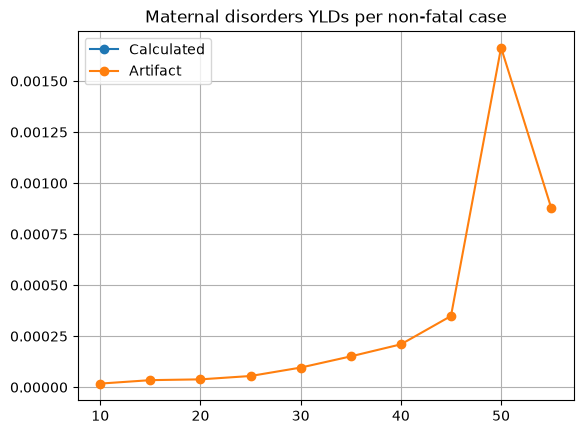

In [38]:
plt.plot(calculated_ylds.age_start, calculated_ylds[0], marker='o', label='Calculated')
plt.plot(art_ylds.age_start, art_ylds[0], marker='o', label='Artifact')
plt.legend()
#plt.semilogy()
plt.grid()
plt.title('Maternal disorders YLDs per non-fatal case')

In [39]:
gbd_csmr = get_outputs(release_id=9,
                    year_id=YEAR_START,
                    sex_id=2,
                    age_group_id=list(range(7,17)),
                    topic='cause',
                    cause_id=366,
                    measure_id=1,
                    metric_id=3,
                    location_id=location_id,
                    #compare_version_id=7948
                      )
gbd_csmr

,age_group_id,cause_id,location_id,measure_id,metric_id,sex_id,year_id,acause,age_group_name,cause_name,expected,location_name,location_type,measure,measure_name,metric_name,sex,val,upper,lower
0,7,366,163,1,3,2,2021,maternal,10 to 14,Maternal disorders,False,India,admin0,death,Deaths,Rate,Female,4.971601e-07,8.252065e-07,3.068646e-07
1,8,366,163,1,3,2,2021,maternal,15 to 19,Maternal disorders,False,India,admin0,death,Deaths,Rate,Female,4.419642e-05,5.302937e-05,3.642242e-05
2,9,366,163,1,3,2,2021,maternal,20 to 24,Maternal disorders,False,India,admin0,death,Deaths,Rate,Female,1.094298e-04,1.335882e-04,8.889170e-05
3,10,366,163,1,3,2,2021,maternal,25 to 29,Maternal disorders,False,India,admin0,death,Deaths,Rate,Female,1.125965e-04,1.375151e-04,9.224878e-05
4,11,366,163,1,3,2,2021,maternal,30 to 34,Maternal disorders,False,India,admin0,death,Deaths,Rate,Female,1.025542e-04,1.240216e-04,8.456613e-05
5,12,366,163,1,3,2,2021,maternal,35 to 39,Maternal disorders,False,India,admin0,death,Deaths,Rate,Female,7.754602e-05,9.472624e-05,6.360313e-05
6,13,366,163,1,3,2,2021,maternal,40 to 44,Maternal disorders,False,India,admin0,death,Deaths,Rate,Female,4.419820e-05,5.460274e-05,3.580774e-05
7,14,366,163,1,3,2,2021,maternal,45 to 49,Maternal disorders,False,India,admin0,death,Deaths,Rate,Female,1.405811e-05,1.785489e-05,1.102424e-05
8,15,366,163,1,3,2,2021,maternal,50 to 54,Maternal disorders,False,India,admin0,death,Deaths,Rate,Female,5.520505e-06,8.664626e-06,3.512201e-06
9,16,366,163,1,3,2,2021,maternal,55 to 59,Maternal disorders,NaN,India,admin0,death,Deaths,Rate,Female,NaN,NaN,NaN


Text(0.5, 1.0, 'MD CSMR')

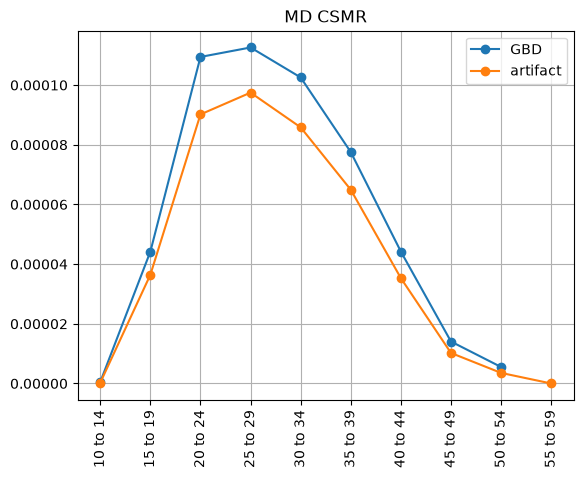

In [40]:
plt.plot(gbd_csmr.age_group_name, gbd_csmr.val, marker='o', label='GBD')
plt.plot(gbd_csmr.age_group_name, art.load('cause.maternal_disorders.cause_specific_mortality_rate').mean(axis=1),
        marker='o', label="artifact")
plt.grid()
plt.xticks(rotation=90)
plt.legend()
plt.title('MD CSMR')

    # These used to exactly replicate eachother... double check year_ids

In [41]:
anemia_pt = pd.read_parquet(results_dir + 'person_time_anemia')
anemia_pt = anemia_pt.loc[anemia_pt.scenario=='baseline']
anemia_pt.head()

,measure,entity_type,entity,sub_entity,age_group,anemia_status_at_birth,wealth_quintile,scenario,input_draw,random_seed,value
0,person_time,impairment,anemia,not_anemic,10_to_14,invalid,1,baseline,0,2,3.660507
1,person_time,impairment,anemia,not_anemic,10_to_14,invalid,2,baseline,0,2,2.338125
2,person_time,impairment,anemia,not_anemic,10_to_14,invalid,3,baseline,0,2,2.893908
3,person_time,impairment,anemia,not_anemic,10_to_14,invalid,4,baseline,0,2,3.123888
4,person_time,impairment,anemia,not_anemic,10_to_14,invalid,5,baseline,0,2,1.130732


In [42]:
(anemia_pt.groupby(['scenario','sub_entity'])['value'].sum() 
 / anemia_pt.groupby(['scenario'])['value'].sum()).reset_index().sort_values(by='sub_entity').dropna()

,scenario,sub_entity,value
0,baseline,not_anemic,0.520573
1,baseline,mild,0.206477
2,baseline,moderate,0.251213
3,baseline,severe,0.021736


In [43]:
cols = ['input_draw','scenario','age_group']
anemia = (anemia_pt.groupby(cols + ['sub_entity'])['value'].sum() 
          / anemia_pt.groupby(cols)['value'].sum()).reset_index().dropna()
anemia = (anemia.groupby([c for c in cols if c != 'input_draw'] + ['sub_entity'])
          ['value'].describe(percentiles=[0.025,0.975]).reset_index())
anemia.head()

,scenario,age_group,sub_entity,count,mean,std,min,2.5%,50%,97.5%,max
0,baseline,10_to_14,not_anemic,1.0,0.436332,NaN,0.436332,0.436332,0.436332,0.436332,0.436332
1,baseline,10_to_14,mild,1.0,0.095542,NaN,0.095542,0.095542,0.095542,0.095542,0.095542
2,baseline,10_to_14,moderate,1.0,0.404106,NaN,0.404106,0.404106,0.404106,0.404106,0.404106
3,baseline,10_to_14,severe,1.0,0.064020,NaN,0.064020,0.064020,0.064020,0.064020,0.064020
4,baseline,15_to_19,not_anemic,1.0,0.503712,NaN,0.503712,0.503712,0.503712,0.503712,0.503712


In [44]:
target =get_draws(
        gbd_id_type='rei_id',
        gbd_id=[205, 206, 207], # Mild, moderate, and severe anemia, respectively. We also have rei_id=192 for all anemia and rei_id=432 for moderate and severe combined
        location_id=location_id,
        population_group_id=16, # pregnant population
        sex_id=2, # female
        year_id=2023,
        release_id=33, # GBD 2023, special publications
        source='como',
        measure_id=[5,3], # prevalence
        metric_id=3, # rate
        age_group_id=[7, 8, 9, 10, 11, 12, 13, 14, 15], # constituent age groups of 10-54 years (169)
    )
target.head()

/ihme/homes/abie/projects/2026/vivarium_gates_lsff_2026/.snakemake_envs/artifact/lib/python3.11/site-packages/get_draws/api.py:194: UserWarning: No version_id was specified, so get_draws will automatically determine a best version ID to use from the given parameters. If you want to retrieve a specific version please pass a version_id directly.
  warnings.warn(


,age_group_id,cause_id,draw_0,draw_1,draw_10,draw_11,draw_12,draw_13,draw_14,draw_15,...,draw_98,draw_99,location_id,measure_id,population_group_id,rei_id,sex_id,year_id,metric_id,version_id
0,7,294,3.945793e-01,2.202881e-01,0.292629,0.177105,1.353744e-01,1.969261e-01,2.086699e-01,1.741766e-01,...,0.221329,1.756899e-01,163,5,16,205,2,2023,3,1773
1,7,295,3.720658e-01,2.072972e-01,0.277731,0.167506,1.285873e-01,1.871061e-01,1.981404e-01,1.651333e-01,...,0.207023,1.672175e-01,163,5,16,205,2,2023,3,1773
2,7,298,8.627158e-07,1.080694e-06,0.000001,0.000001,5.412338e-07,8.840512e-07,7.218272e-07,7.054266e-07,...,0.000002,4.543730e-07,163,5,16,205,2,2023,3,1773
3,7,300,7.866712e-07,9.984694e-07,0.000001,0.000001,5.000127e-07,8.301703e-07,6.800916e-07,6.547092e-07,...,0.000002,4.264038e-07,163,5,16,205,2,2023,3,1773
4,7,344,3.712301e-02,2.051935e-02,0.027868,0.016854,1.285184e-02,1.863539e-02,1.986870e-02,1.655211e-02,...,0.020515,1.675515e-02,163,5,16,205,2,2023,3,1773


In [45]:
#Had to do some manual adjustments to make the draw list include all the modulo ones.  

print(anemia_pt.input_draw.unique())
draw_list = [3, 41, 21, 13, 39, 16, 99, 77, 8, 92]
draw_list

[0]


[3, 41, 21, 13, 39, 16, 99, 77, 8, 92]

In [46]:
target_test = target.copy()
target_test["severity"] = target_test["rei_id"].map({205: "mild",206: "moderate",207: "severe"})
target_test = target_test.merge(get_ids('age_group'), on='age_group_id')
target_test['age_group'] = target_test.age_group_name.str.replace(' ', '_')
target_test=target_test.loc[(target_test.cause_id==294)]
target_test = target_test[[c for c in target_test.columns if not c.startswith("draw_")] +[f"draw_{x}" for x in draw_list if f"draw_{x}" in target_test.columns]]
draw_cols = [c for c in target_test.columns if c.startswith("draw_")]
id_cols = [c for c in target_test.columns if not c.startswith("draw_")]
target_test = target_test.melt(id_vars=id_cols,value_vars=draw_cols,var_name="draw",value_name="value")
target_prev = target_test.loc[target_test.measure_id==5]
target_ylds = target_test.loc[target_test.measure_id==3]
target_prev = target_prev.groupby(['age_group','severity'])['value'].describe(percentiles=[0.025,0.975]).reset_index()
target_ylds = target_ylds.groupby(['age_group','draw']).value.sum().groupby('age_group').describe(percentiles=[0.025,0.975]).reset_index()
target_prev.head()

,age_group,severity,count,mean,std,min,2.5%,50%,97.5%,max
0,10_to_14,mild,10.0,0.214631,0.068579,0.122094,0.131014,0.203471,0.347128,0.372930
1,10_to_14,moderate,10.0,0.268349,0.043463,0.201702,0.206516,0.269676,0.336175,0.342034
2,10_to_14,severe,10.0,0.033963,0.018182,0.008345,0.010982,0.035190,0.068032,0.075449
3,15_to_19,mild,10.0,0.230980,0.043894,0.169786,0.173744,0.223295,0.315724,0.331721
4,15_to_19,moderate,10.0,0.288077,0.014485,0.265687,0.267345,0.284579,0.310365,0.310682


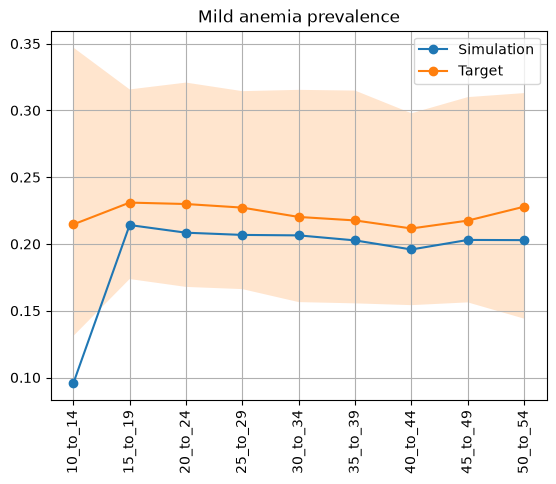

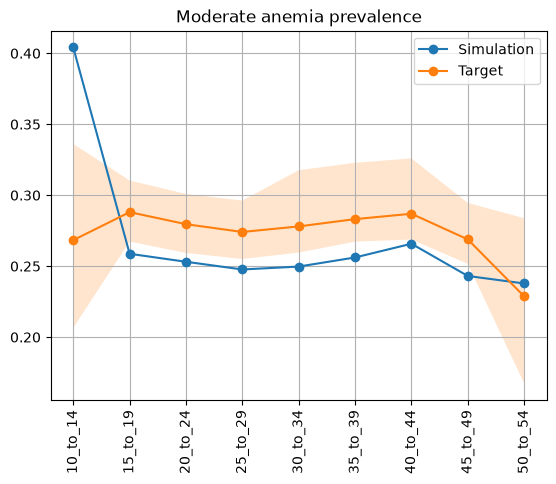

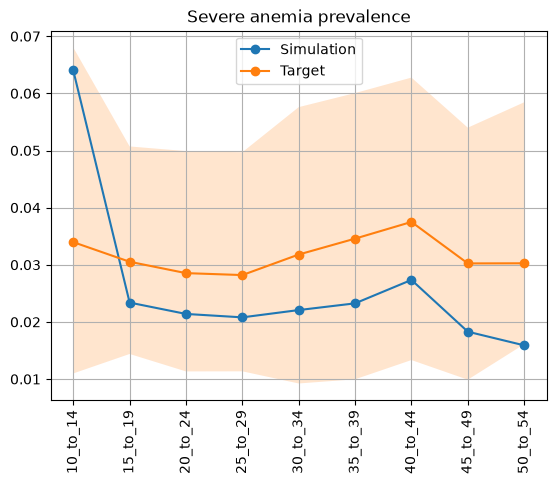

In [47]:
for sev in ['mild','moderate','severe']:
    s = anemia.loc[anemia.sub_entity==sev]
    plt.plot(s.age_group, s['mean'], marker='o', label='Simulation')
    plt.fill_between(s.age_group, s['2.5%'], s['97.5%'], alpha=0.2)
    t = target_prev.loc[target_prev.severity==sev]
    plt.plot(t.age_group, t['mean'], marker='o', label='Target')
    plt.fill_between(t.age_group, t['2.5%'], t['97.5%'], alpha=0.2)
    plt.grid()
    plt.legend()
    plt.xticks(rotation=90)
    plt.title(f'{sev.title()} anemia prevalence')
    plt.show()

In [48]:
# NOTE: the target and the output are a bit of a mismatch here. I updates to the new target code that is for GBD 2023, but the 
# artifact was made with the old version of hemoglobin. Some mismatch is expected. 
# This should resolve with the GBD 2023 version. If it does not, then it's a problem! 

In [49]:
anemia_ylds = ylds.loc[(ylds.sub_entity=='anemia')&(ylds.scenario=='baseline')]
pt = pd.read_parquet(results_dir + 'person_time_pregnancy')
pt = pt.loc[pt.scenario=='baseline']
anemia_ylds = (anemia_ylds.groupby(['input_draw','age_group']).sum()[['value']] 
               / pt.groupby(['input_draw','age_group']).sum()[['value']]
               #* (52/36)
              )
anemia_ylds = anemia_ylds.groupby(['age_group']).value.describe(percentiles=[0.025,0.975]).reset_index()
anemia_ylds = anemia_ylds.fillna(0)
anemia_ylds

/tmp/ipykernel_3070051/2636933537.py:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  anemia_ylds = (anemia_ylds.groupby(['input_draw','age_group']).sum()[['value']]
/tmp/ipykernel_3070051/2636933537.py:5: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  / pt.groupby(['input_draw','age_group']).sum()[['value']]


,age_group,count,mean,std,min,2.5%,50%,97.5%,max
0,10_to_14,1.0,0.030227,0.0,0.030227,0.030227,0.030227,0.030227,0.030227
1,15_to_19,1.0,0.017412,0.0,0.017412,0.017412,0.017412,0.017412,0.017412
2,20_to_24,1.0,0.016798,0.0,0.016798,0.016798,0.016798,0.016798,0.016798
3,25_to_29,1.0,0.016406,0.0,0.016406,0.016406,0.016406,0.016406,0.016406
4,30_to_34,1.0,0.016680,0.0,0.016680,0.016680,0.016680,0.016680,0.016680
5,35_to_39,1.0,0.017146,0.0,0.017146,0.017146,0.017146,0.017146,0.017146
6,40_to_44,1.0,0.018191,0.0,0.018191,0.018191,0.018191,0.018191,0.018191
7,45_to_49,1.0,0.015734,0.0,0.015734,0.015734,0.015734,0.015734,0.015734
8,50_to_54,1.0,0.015029,0.0,0.015029,0.015029,0.015029,0.015029,0.015029
9,55_to_59,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000


Text(0.5, 1.0, 'Anemia YLD rate')

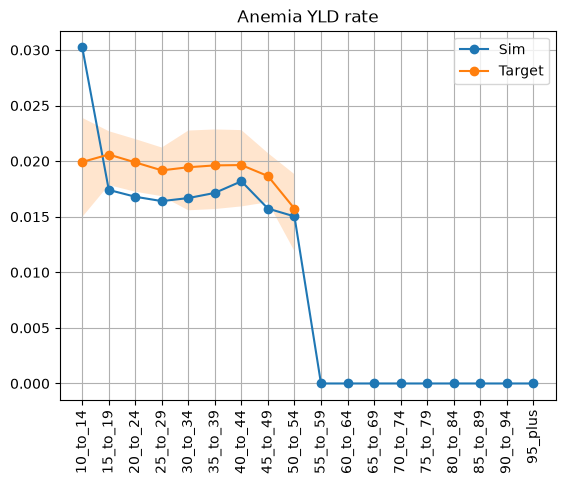

In [50]:
plt.plot(anemia_ylds.age_group, anemia_ylds['mean'], marker='o', label='Sim')
plt.fill_between(anemia_ylds.age_group, anemia_ylds['2.5%'], anemia_ylds['97.5%'], alpha=0.2)
plt.plot(target_ylds.age_group, target_ylds['mean'], marker='o', label='Target')
plt.fill_between(target_ylds.age_group, target_ylds['2.5%'], target_ylds['97.5%'], alpha=0.2)
plt.xticks(rotation=90)
plt.legend()
plt.grid()
#plt.ylim(ymax=0.05)
plt.title('Anemia YLD rate')

# ok this used to be meeting target in model 12.0 but looks off here

In [51]:
# Same here! The GBD rounds are not aligned. Confirm that this is fixed in the GBD 2023 version 